# Milestone 3 Objective

Integrate the Orchestrator Agent and Repository Analyzer Agent into one main LangGraph workflow.

## Why Integrate Only Now

The Orchestrator and Repository Analyzer were tested alone first. This milestone connects only those two agents so the State handoff can be verified before adding RAG, planning, testing, bug analysis, or reporting agents.

## Integrated LangGraph Workflow

```text
START -> orchestrator -> repo_analyzer -> END
```

The edge after Orchestrator is conditional: it can route to `repo_analyzer` or directly to `END`.

## State Handoff

The Orchestrator writes `run_id`, `selected_agents`, and `orchestrator_decision`. The Repository Analyzer then uses the same `run_id` plus `repo_url` or `repo_path` to write `project_info`, `discovered_endpoints`, `discovered_ui_flows`, and `indexed_documents`.

## Security Note

The graph only reads or clones repository files. It does not run the Django server, execute target repository code, call LLM APIs, or print secrets.

## Target Repository

https://github.com/Vitaee/DjangoRestAPI

## Part A - Fake Repository Integration

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

from test_auto.graph.workflow import run_workflow

In [2]:
from tempfile import TemporaryDirectory

tmp = TemporaryDirectory()
fake_repo_path = Path(tmp.name) / "fake_django_rest_repo"

def write_file(relative_path: str, content: str = "") -> None:
    path = fake_repo_path / relative_path
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(content, encoding="utf-8")

write_file("README.md", "# Fake Django REST API\n")
write_file("requirements.txt", "django\ndjangorestframework\ndjangorestframework-simplejwt\n")
write_file("manage.py", "# placeholder\n")
write_file(
    "todo/urls.py",
    '\n'.join([
        "from django.urls import path",
        "urlpatterns = [",
        '    path("api/todos/", views.todo_list),',
        "]",
    ]),
)
write_file("templates/login.html", "<form>login</form>\n")

fake_repo_path

WindowsPath('C:/Users/malak/AppData/Local/Temp/tmpe1g24j32/fake_django_rest_repo')

In [3]:
initial_state = {
    "repo_path": str(fake_repo_path),
    "target_url": "http://localhost:8000",
    "user_preferences": {
        "test_types": ["api", "ui"],
        "execution_mode": "sequential",
    },
    "errors": [],
    "agent_logs": [],
}

final_state = run_workflow(initial_state)

In [4]:
import json

print(json.dumps(final_state, indent=2))

{
  "run_id": "run_20260520T084003Z_32805fe0",
  "target_url": "http://localhost:8000",
  "user_preferences": {
    "test_types": [
      "api",
      "ui"
    ],
    "execution_mode": "sequential"
  },
  "selected_agents": [
    "repository_analyzer",
    "rag",
    "test_planner",
    "api",
    "ui",
    "bug",
    "report"
  ],
  "orchestrator_decision": {
    "run_id": "run_20260520T084003Z_32805fe0",
    "selected_agents": [
      "repository_analyzer",
      "rag",
      "test_planner",
      "api",
      "ui",
      "bug",
      "report"
    ],
    "execution_mode": "sequential",
    "reasoning_summary": "Selected future agents from requested test types using deterministic milestone-1 rules. No testing agent was executed.",
    "risks": [],
    "next_node": "repository_analyzer"
  },
  "errors": [],
  "agent_logs": [
    {
      "agent": "orchestrator",
      "timestamp": "2026-05-20T08:40:03.370215+00:00",
      "status": "success",
      "duration_seconds": 0.0005090999766252

In [5]:
{
    "selected_agents": final_state.get("selected_agents"),
    "project_info": final_state.get("project_info"),
    "discovered_endpoints": final_state.get("discovered_endpoints"),
    "workflow_state_path": final_state.get("workflow_state_path"),
}

{'selected_agents': ['repository_analyzer',
  'rag',
  'test_planner',
  'api',
  'ui',
  'bug',
  'report'],
 'project_info': {'language': 'Python',
  'framework': 'Django REST Framework',
  'test_framework': None,
  'has_api': True,
  'has_ui': True,
  'auth_type': 'JWT',
  'package_manager': 'pip',
  'source_dirs': ['todo'],
  'test_dirs': [],
  'candidate_docs': ['README.md'],
  'candidate_api_files': ['todo/urls.py'],
  'candidate_ui_files': ['templates/login.html'],
  'risks': ['No obvious test files or test configuration were found.']},
 'discovered_endpoints': [{'name': 'api_todos',
   'method': 'UNKNOWN',
   'path': '/api/todos/',
   'source_file': 'todo/urls.py',
   'line_number': 3,
   'confidence': 0.7}],
 'workflow_state_path': 'results\\runs\\run_20260520T084003Z_32805fe0\\workflow_state.json'}

## Part B - Optional Real Target Repository

The next cell requires internet access and `git`. It clones files for analysis only; it does not run the Django project.

In [6]:
target_repo_url = "https://github.com/Vitaee/DjangoRestAPI"
RUN_REAL_TARGET = False

if RUN_REAL_TARGET:
    real_state = run_workflow({
        "repo_url": target_repo_url,
        "target_url": "http://localhost:8000",
        "user_preferences": {
            "test_types": ["api", "ui"],
            "execution_mode": "sequential",
        },
        "errors": [],
        "agent_logs": [],
    })
    print(json.dumps({
        "project_info": real_state.get("project_info"),
        "output_files": real_state.get("output_files"),
    }, indent=2))
else:
    print("Set RUN_REAL_TARGET = True to clone and analyze the GitHub repository.")

Set RUN_REAL_TARGET = True to clone and analyze the GitHub repository.


## Part C - Graph Visualization

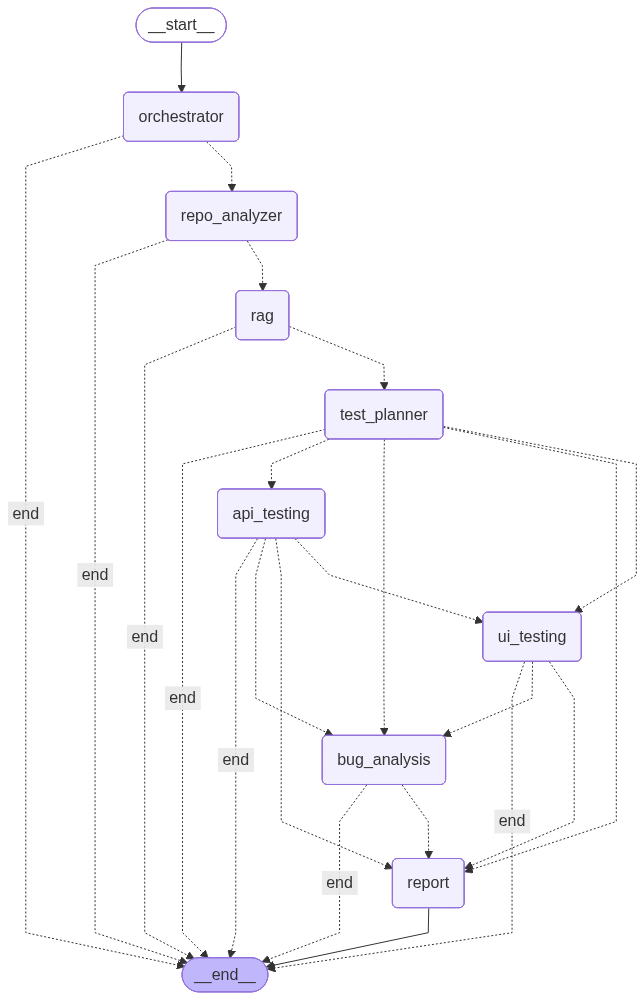

In [7]:
from test_auto.graph.workflow import build_graph

graph = build_graph()
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    try:
        print(graph.get_graph().draw_mermaid())
    except Exception:
        print("Graph: START -> orchestrator -> repo_analyzer or END -> END")
        print(f"Visualization error: {exc}")